## XGBoost model for Water Pipe Failure Prediction (Joe Tambeana)
#### Purpose

This notebook builds a **baseline Random Forest classification model** using the **Kitchener model-ready dataset** to predict whether a water pipe has experienced a break (`has_break`).

A **classification model** is used instead of regression because it aligns better with the goal of building a **risk identification system**.
Rather than predicting a continuous failure rate, the model estimates whether a pipe is likely to fall into a break-risk category, which is more practical for future prioritisation and maintenance planning.

#### Expected outputs
By the end of this notebook, this Random Forest workflow should deliver:

- A **baseline pipe failure risk model** that predicts whether a water pipe has experienced a break (`has_break`)
- A **methodologically clean modelling process** using separate train, validation, and test sets
- A **tuned final Random Forest classifier** suitable for fair comparison with other models
- **Final evaluation metrics on the unseen test set**, including:
  - ROC-AUC
  - PR-AUC
  - Precision
  - Recall
  - F1-score
- A **confusion matrix** to show how well the model identifies break vs no-break pipes
- A **feature importance ranking** to highlight the strongest drivers of pipe failure risk
- A **probability-based risk output** that can be used later to:
  - rank pipes by risk level
  - support maintenance prioritisation
  - provide an interpretable foundation for future LLM-based maintenance recommendation workflows

#### Note
- **Training set** → fit the model
- **Validation set** → tune and compare model performance
- **Test set** → final unbiased evaluation

This makes the Random Forest results easier to compare fairly with other models in the later stage.

### Import libraries & Environment setup

In [39]:

import pandas as pd
import optuna # For hyperparameter tuning
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, 
    classification_report, roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score)
import matplotlib.pyplot as plt
import seaborn as sns # For data visualization
import shap # For model interpretability
import optuna  # For hyperparameter tuning
import warnings
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

### Loading dataset & Initial inspection

In [ ]:
df = pd.read_csv('..data/processed/kitchener_model_ready.csv')  
print("Shape:", df.shape)
print(df.head())
print(df.info())
print(df['has_break'].value_counts())
print(df['has_break'].value_counts(normalize=True))

Shape: (16163, 20)
  pressure_zone category  pipe_size material  lined lined_material  \
0         KIT 6  TREATED        450       DI      0           NONE   
1         KIT 4  TREATED        300       DI      0           NONE   
2         KIT 6  TREATED        450       DI      0           NONE   
3         KIT 6  TREATED        450       DI      0           NONE   
4         KIT 6  TREATED        450       DI      0           NONE   

  acquisition             ownership  bridge_main  criticality  \
0     DONATED  DUAL CITY AND REGION            0          6.0   
1   PURCHASED                REGION            0          7.0   
2     DONATED  DUAL CITY AND REGION            0          7.0   
3     DONATED  DUAL CITY AND REGION            0          6.0   
4     DONATED  DUAL CITY AND REGION            0          6.0   

   rel_cleaning_area rel_cleaning_subarea  undersized  shallow_main  \
0                  6                    8           0             0   
1                  1       

### Train-Test Split (Stratified)

The data is split into **70% train**, **15% validation**, and **15% test** sets.  
Stratified splitting is used to ensure the `has_break` class distribution remains consistent across all subsets.

In [41]:
# First split: 70% training, 30% temporary (to be further split into validation and test)
target = 'has_break'

X = df.drop(columns=[target])
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Second split: 15% validation, 15% test from the temporary set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

# Print shapes and class distributions to verify the splits are correct and maintain class balance 
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))


Train shape: (11314, 19)
Validation shape: (2424, 19)
Test shape: (2425, 19)

Train target distribution:
has_break
0    0.923634
1    0.076366
Name: proportion, dtype: float64

Validation target distribution:
has_break
0    0.92368
1    0.07632
Name: proportion, dtype: float64

Test target distribution:
has_break
0    0.923711
1    0.076289
Name: proportion, dtype: float64


### Encoding of Categorical Features

- To prepare the dataset for modelling, the categorical columns are converted into numeric indicator columns 

- The validation and test sets are then aligned to the training feature space to ensure all three sets have the exact same columns.

In [42]:
# Separate features and target
# The target variable is 'has_break', which indicates whether a pipe has experienced a break (1) or not (0)
cat_cols = ['pressure_zone', 'category', 'material', 'lined_material',
            'acquisition', 'ownership', 'rel_cleaning_subarea']

for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_val[col]   = X_val[col].astype('category')
    X_test[col]  = X_test[col].astype('category')

# 4. Check
print("Categorical dtypes after conversion:")
print(X_train[cat_cols].dtypes)

Categorical dtypes after conversion:
pressure_zone           category
category                category
material                category
lined_material          category
acquisition             category
ownership               category
rel_cleaning_subarea    category
dtype: object


### Train the XGBoost model with Early stopping - Validation set
- Early stopping is used in XGBoost to prevent overfitting and find optimal number of trees automatically.


In [43]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

eval_set = [(X_train, y_train), (X_val, y_val)]   # Training first, then Validation

# Define evaluation set for early stopping
eval_set = [(X_val, y_val), (X_train, y_train)]

model = xgb.XGBClassifier(
    n_estimators=1000,                      # Start with a large number of trees and use early stopping to find the optimal number
    max_depth=5,                            # Moderate depth to prevent overfitting
    learning_rate=0.03,                     # Lower learning rate for better generalization
    subsample=0.75,                         # Use 75% of the data for each tree to prevent overfitting
    colsample_bytree=0.75,                  # Use 75% of the features for each tree to prevent overfitting
    min_child_weight=5,                     # Minimum sum of instance weight needed in a child to prevent overfitting
    gamma=0.5,                              # Minimum loss reduction required to make a further partition on a leaf node of the tree
    scale_pos_weight=scale_pos_weight,      # Handle class imbalance by giving more weight to the minority class    
    eval_metric=['aucpr', 'auc', 'logloss'],# Use multiple evaluation metrics
    random_state=42,                        # Set random seed for reproducibility   
    n_jobs=-1,                              # Use all available CPU cores for faster training
    verbosity=1,                            # Set verbosity to 1 to see training progress
    early_stopping_rounds=60,               # Stop training if validation AUC does not improve for 60 rounds
    enable_categorical=True                 # Enable native handling of categorical features
)

model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=50
)

# ============================
# 3. Get Best Iteration & Metrics
# ============================
evals_result = model.evals_result()
best_iter = model.best_iteration

# Correct indexing: validation_1 = validation set
best_val_pr_auc = evals_result['validation_1']['aucpr'][best_iter]
best_val_auc    = evals_result['validation_1']['auc'][best_iter]

print(f"\nBest iteration: {best_iter}")
print(f"Best validation PR-AUC : {best_val_pr_auc:.4f}")
print(f"Best validation ROC-AUC: {best_val_auc:.4f}")

scale_pos_weight: 12.09
[0]	validation_0-aucpr:0.45977	validation_0-auc:0.86027	validation_0-logloss:0.67798	validation_1-aucpr:0.50065	validation_1-auc:0.89626	validation_1-logloss:0.67790
[50]	validation_0-aucpr:0.96135	validation_0-auc:0.99106	validation_0-logloss:0.18819	validation_1-aucpr:0.97155	validation_1-auc:0.99765	validation_1-logloss:0.18897
[100]	validation_0-aucpr:0.96583	validation_0-auc:0.99076	validation_0-logloss:0.08480	validation_1-aucpr:0.98199	validation_1-auc:0.99859	validation_1-logloss:0.08385
[150]	validation_0-aucpr:0.97027	validation_0-auc:0.99204	validation_0-logloss:0.05781	validation_1-aucpr:0.98850	validation_1-auc:0.99912	validation_1-logloss:0.05544
[200]	validation_0-aucpr:0.97189	validation_0-auc:0.99246	validation_0-logloss:0.04522	validation_1-aucpr:0.99208	validation_1-auc:0.99941	validation_1-logloss:0.04130
[250]	validation_0-aucpr:0.97109	validation_0-auc:0.99206	validation_0-logloss:0.04101	validation_1-aucpr:0.99383	validation_1-auc:0.99954	

### Model Evaluation on Validation set
- The model is first evaluated on the validation set
- This will give an initial view of model performance before tuning, while keeping the test set untouched for final evaluation later.


In [44]:
y_val_proba = model.predict_proba(X_val)[:, 1]
y_val_pred  = model.predict(X_val)

print("\n" + "="*60)
print("VALIDATION SET EVALUATION")
print("="*60)

print(f"ROC-AUC      : {roc_auc_score(y_val, y_val_proba):.4f}")
print(f"PR-AUC       : {average_precision_score(y_val, y_val_proba):.4f}")
print(f"Precision    : {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall       : {recall_score(y_val, y_val_pred):.4f}")
print(f"F1-score     : {f1_score(y_val, y_val_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=['No Break', 'Break']))


VALIDATION SET EVALUATION
ROC-AUC      : 0.9902
PR-AUC       : 0.9686
Precision    : 0.9667
Recall       : 0.9405
F1-score     : 0.9534

Confusion Matrix:
[[2233    6]
 [  11  174]]

Classification Report:
              precision    recall  f1-score   support

    No Break       1.00      1.00      1.00      2239
       Break       0.97      0.94      0.95       185

    accuracy                           0.99      2424
   macro avg       0.98      0.97      0.97      2424
weighted avg       0.99      0.99      0.99      2424



#### Evaluation results
- The model performed very well with accuracy high accuracy of 99% 
- Excellence performance for break detection for precision, recall and f1-score above 0.94

### Hyperparameter Tuning
- Tuning the hyperparameters helps to find a better balance between fitting the training data and generalizing to new data.
- Small improvements needed on PR-AUC, precision, recall or F1-score
   

In [45]:
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        'subsample': trial.suggest_float('subsample', 0.65, 0.90),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.65, 0.90),
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 12),
        'gamma': trial.suggest_float('gamma', 0.1, 2.0),
        'scale_pos_weight': scale_pos_weight,
        'n_estimators': 1000,
        'random_state': 42,
        'enable_categorical': True,
        'eval_metric': 'aucpr',
        'early_stopping_rounds': 60
    }
    
    model = xgb.XGBClassifier(**params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    val_proba = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, val_proba)


# Run Optuna
study = optuna.create_study(direction='maximize', study_name='pipe_failure_xgboost')
print("Starting Optuna tuning... (this will take some time)")
study.optimize(objective, n_trials=40)   # 40 trials is a good balance

# Run Optuna
study = optuna.create_study(direction='maximize', study_name='pipe_failure_xgboost')
print("Starting Optuna tuning... (this will take some time)")
study.optimize(objective, n_trials=40)   # 40 trials is a good balance

print("\n=== Optuna Tuning Completed ===")
print("Best hyperparameters:", study.best_params)
print("Best Validation PR-AUC:", round(study.best_value, 4))

[I 2026-04-18 21:00:16,824] A new study created in memory with name: pipe_failure_xgboost


Starting Optuna tuning... (this will take some time)


[I 2026-04-18 21:00:17,739] Trial 0 finished with value: 0.9694887550525576 and parameters: {'max_depth': 6, 'learning_rate': 0.014442891802207022, 'subsample': 0.751528043975218, 'colsample_bytree': 0.8766945052683469, 'min_child_weight': 12, 'gamma': 0.3353285875847663}. Best is trial 0 with value: 0.9694887550525576.
[I 2026-04-18 21:00:18,031] Trial 1 finished with value: 0.9703439858491038 and parameters: {'max_depth': 4, 'learning_rate': 0.061995390343538764, 'subsample': 0.6890819516130973, 'colsample_bytree': 0.6901599998394895, 'min_child_weight': 10, 'gamma': 1.3007591460337964}. Best is trial 1 with value: 0.9703439858491038.
[I 2026-04-18 21:00:18,294] Trial 2 finished with value: 0.9715310360789116 and parameters: {'max_depth': 6, 'learning_rate': 0.06801481694848588, 'subsample': 0.7412629643343938, 'colsample_bytree': 0.7264601158713087, 'min_child_weight': 5, 'gamma': 1.1960357839345166}. Best is trial 2 with value: 0.9715310360789116.
[I 2026-04-18 21:00:18,606] Trial 

Starting Optuna tuning... (this will take some time)


[I 2026-04-18 21:00:34,193] Trial 0 finished with value: 0.9711626588955323 and parameters: {'max_depth': 5, 'learning_rate': 0.011767589267768979, 'subsample': 0.8180782802048135, 'colsample_bytree': 0.7416058672405346, 'min_child_weight': 8, 'gamma': 1.7926705766696314}. Best is trial 0 with value: 0.9711626588955323.
[I 2026-04-18 21:00:34,984] Trial 1 finished with value: 0.9699434187245413 and parameters: {'max_depth': 6, 'learning_rate': 0.01715463385547362, 'subsample': 0.8153872640941388, 'colsample_bytree': 0.7854233509427353, 'min_child_weight': 10, 'gamma': 1.3888971983125873}. Best is trial 0 with value: 0.9711626588955323.
[I 2026-04-18 21:00:35,122] Trial 2 finished with value: 0.9533160049661175 and parameters: {'max_depth': 6, 'learning_rate': 0.012998515790770748, 'subsample': 0.8335747404769276, 'colsample_bytree': 0.8908590729890519, 'min_child_weight': 11, 'gamma': 0.5581513550358356}. Best is trial 0 with value: 0.9711626588955323.
[I 2026-04-18 21:00:35,295] Trial


=== Optuna Tuning Completed ===
Best hyperparameters: {'max_depth': 5, 'learning_rate': 0.043260762634730755, 'subsample': 0.7425483660215291, 'colsample_bytree': 0.7306400689857374, 'min_child_weight': 8, 'gamma': 0.47507679246080564}
Best Validation PR-AUC: 0.9731


### Retraining the model on Training + Validation set
- After the selection of the best hyperparameters, the final model is retrained using the combined training and validation data.
- Using all the available labeled data for final training, so the model becomes as strong as possible

In [46]:
best_params = study.best_params

# Remove parameters that shouldn't go into constructor
best_params.pop('early_stopping_rounds', None)
best_params.pop('n_estimators', None)   # we'll control it separately

X_train_val = pd.concat([X_train, X_val], ignore_index=True)
y_train_val = pd.concat([y_train, y_val], ignore_index=True)

# Fix dtypes
cat_cols = X_train_val.select_dtypes(include=['object', 'string']).columns.tolist()
for col in cat_cols:
    X_train_val[col] = X_train_val[col].astype('category')

final_model = xgb.XGBClassifier(
    **best_params,
    n_estimators=800,                    # safe upper limit
    random_state=42,
    enable_categorical=True,
    eval_metric='aucpr'
)

final_model.fit(X_train_val, y_train_val, verbose=False)
print("Final model retrained on Train + Validation using best hyperparameters.")

Final model retrained on Train + Validation using best hyperparameters.


### Model Evaluation on Test set

This final model is now evaluated on the unseen test set.

This is the most important evaluation step, because it shows how well the tuned XGBoost generalises to new data that was not used during training or tuning.

The key metrics reported here are:

- ROC-AUC for overall class separation
- PR-AUC for minority-class performance
- Precision
- Recall
- F1-score

In [47]:
y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred = final_model.predict(X_test)

print("\n" + "="*70)
print("FINAL EVALUATION ON TEST SET")
print("="*70)

print(f"ROC-AUC      : {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"PR-AUC       : {average_precision_score(y_test, y_test_proba):.4f}")
print(f"Precision    : {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall       : {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-score     : {f1_score(y_test, y_test_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No Break', 'Break']))


FINAL EVALUATION ON TEST SET
ROC-AUC      : 0.9899
PR-AUC       : 0.9577
Precision    : 0.9471
Recall       : 0.9676
F1-score     : 0.9572

Confusion Matrix:
[[2230   10]
 [   6  179]]

Classification Report:
              precision    recall  f1-score   support

    No Break       1.00      1.00      1.00      2240
       Break       0.95      0.97      0.96       185

    accuracy                           0.99      2425
   macro avg       0.97      0.98      0.98      2425
weighted avg       0.99      0.99      0.99      2425



#### Results intepretation
- XGBoost performs exceptionally well — this is a strong result for a real-world pipe failure prediction task.
- It achieves excellent class separation and strong minority-class performance, with both precision, recall and f1-score above 0.95 for the break class. 
- This suggests the model is effective at identifying high-risk pipes while maintaining a low level of false alarms.

### Model Evaluation Accuracy and Performance
-  Using the heatmap that helps to quickly identify correct and incorrect prediction

ROC-AUC: 0.9898624517374519
PR-AUC: 0.957717861706749

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2240
           1       0.95      0.97      0.96       185

    accuracy                           0.99      2425
   macro avg       0.97      0.98      0.98      2425
weighted avg       0.99      0.99      0.99      2425



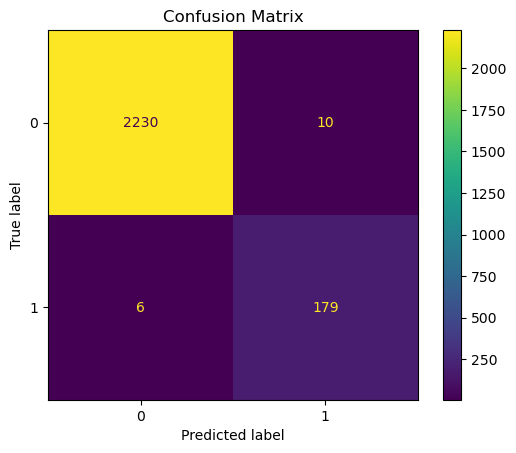

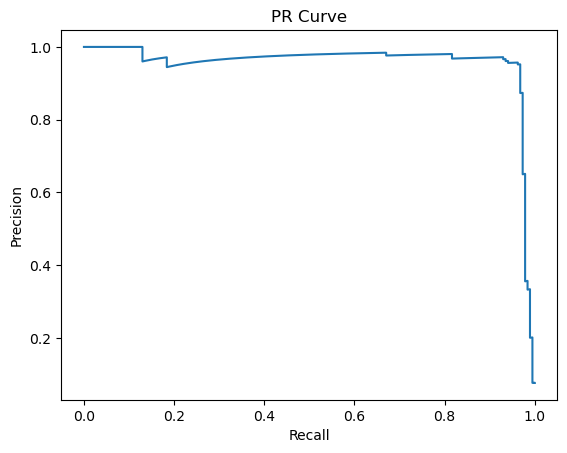

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve

# Evaluate final model performance on the test set
y_pred = final_model.predict(X_test)
y_pred_prob = final_model.predict_proba(X_test)[:, 1]

# Print evaluation metrics
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))
print("PR-AUC:", average_precision_score(y_test, y_pred_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix')
plt.show()

# Precision-Recall curve  
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve')
plt.show()

### Ploting Feature Importance
- Visualizing the importance of each feature in the XGBoost model to understand which variables contribute most to predictions
- It is crucial for understanding pipe failure risks and for making informed maintenance decisions.

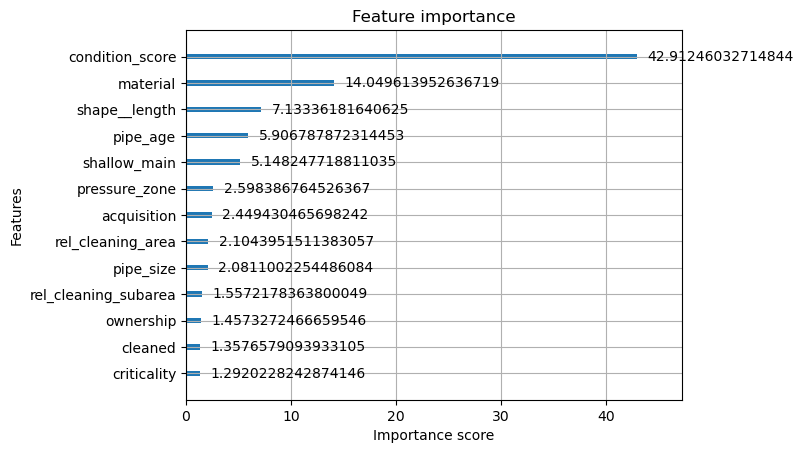

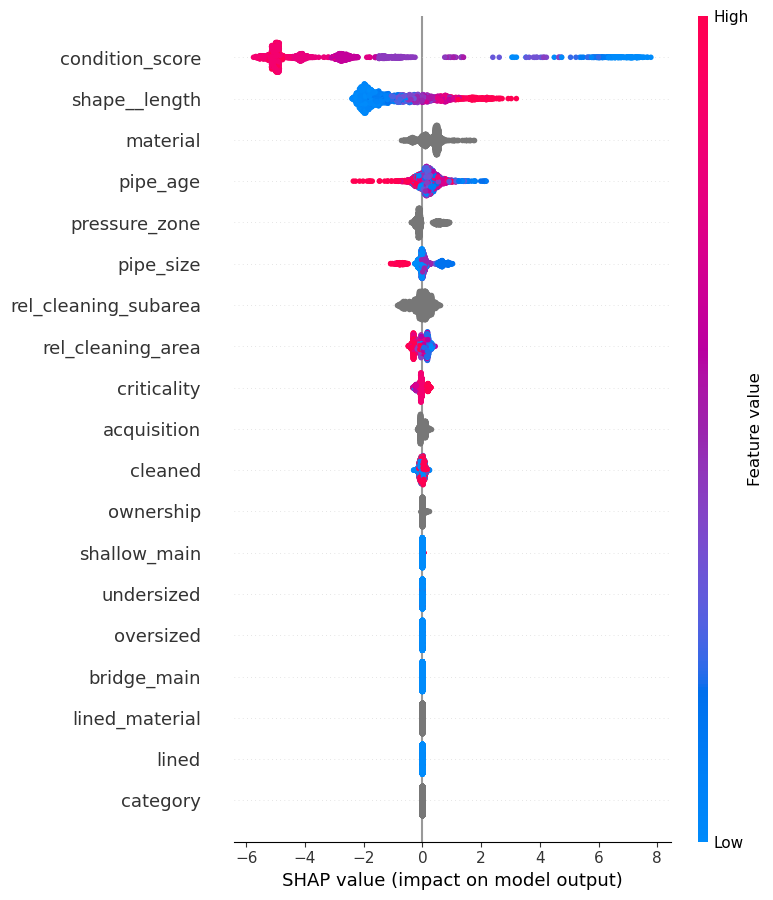

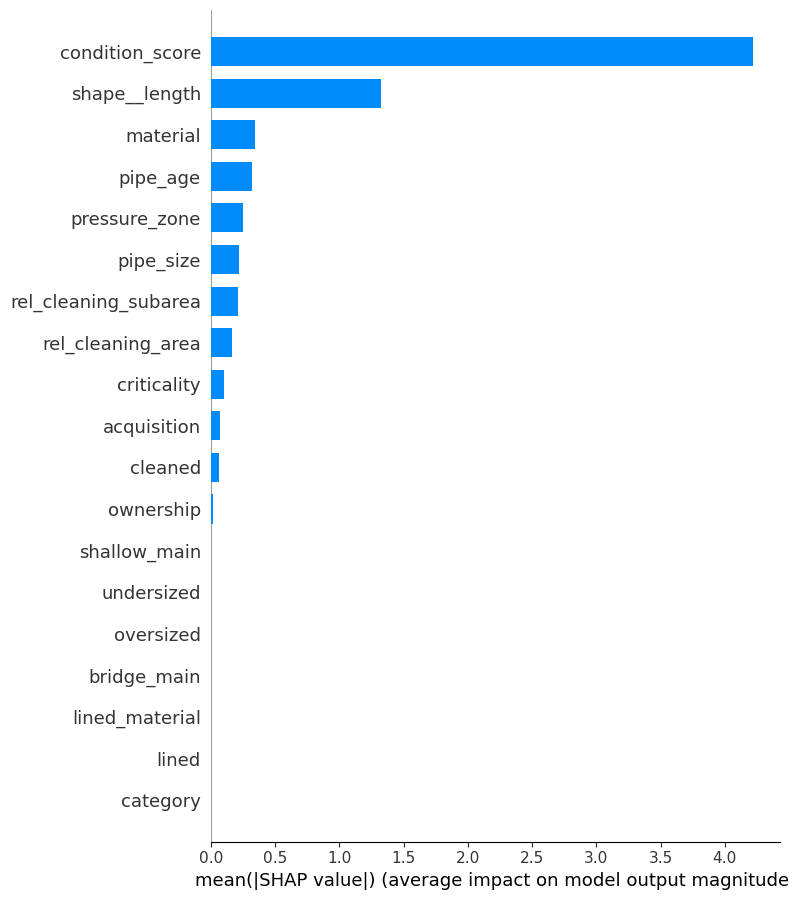

In [49]:
# Feature importance - using 'gain' to see which features contribute most to improving the model's performance.
xgb.plot_importance(final_model, importance_type='gain', max_num_features=15)
plt.show()

# SHAP - highly recommended for pipe failure interpretability
explainer = shap.TreeExplainer(final_model)
# SHAP values provide insights into how each feature contributes to the model's predictions. 
# This is crucial for understanding pipe failure risks and for making informed maintenance decisions.
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")